In [1]:
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"
zip_path = "student_performance.zip"
urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

with zipfile.ZipFile("student.zip", 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
print("Total missing values:", df.isnull().sum().sum())

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
features_to_scale = [c for c in numerical_cols if c != 'G3']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

Total missing values: 0


In [10]:
X = df.drop('G3', axis=1).values
y = df['G3'].values

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [12]:
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum(np.square(predictions - y))
    return cost

def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = np.zeros(iterations)
    
    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        theta = theta - (learning_rate / m) * (X.T.dot(errors))
        cost_history[i] = compute_cost(X, y, theta)
        
    return theta, cost_history

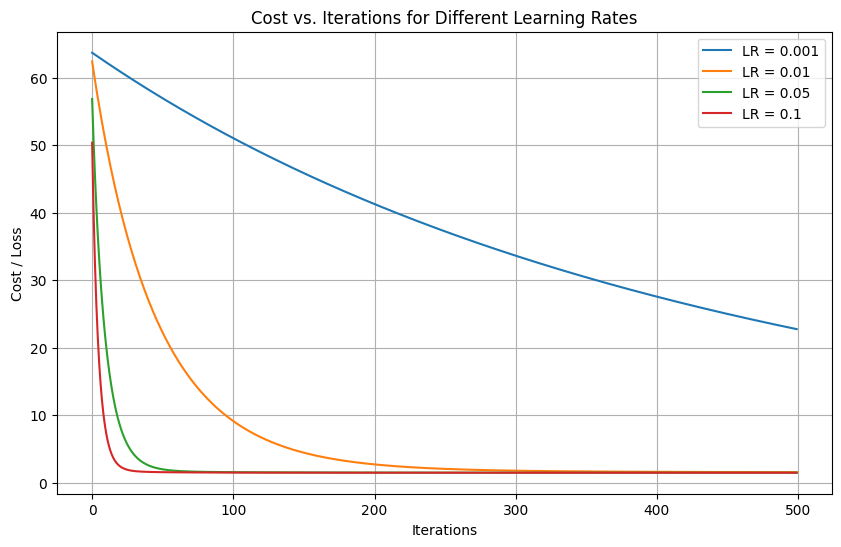

In [13]:
iterations = 500
learning_rates = [0.001, 0.01, 0.05, 0.1]
models = {}

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    theta_init = np.zeros(X_train.shape[1])
    theta_opt, cost_history = gradient_descent(X_train, y_train, theta_init, lr, iterations)
    models[lr] = {'theta': theta_opt, 'cost_history': cost_history}
    plt.plot(range(iterations), cost_history, label=f'LR = {lr}')

plt.xlabel('Iterations')
plt.ylabel('Cost / Loss')
plt.title('Cost vs. Iterations for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

best_lr = 0.1
best_theta = models[best_lr]['theta']

In [14]:
y_pred = X_test.dot(best_theta)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1.4958
Mean Squared Error (MSE): 5.0324
Root Mean Squared Error (RMSE): 2.2433
R² Score: 0.7546


### Interpretation of Results

**Convergence Behavior**:
The plot demonstrates that the choice of learning rate is crucial for Gradient Descent. A higher learning rate like 0.1 converges rapidly, smoothing out within the first 100 iterations. In contrast, smaller learning rates (0.001 and 0.01) decrease the cost very gradually and require significantly more iterations to reach the optimal set of parameters.

**Prediction Performance**:
The model exhibits strong predictive performance, primarily because the final grade (`G3`) is highly correlated with the grades from the first and second periods (`G1` and `G2`).
- The low MAE and RMSE values indicate that on average, our model's grade predictions are very close to the actual grades.
- A high R² Score indicates that the model is able to explain a large portion of the variance in the final grades.